In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.func import grad
import scipy
import scipy.special
import scipy.linalg
from scipy.linalg import toeplitz, cholesky
from gaussian_crossings import (
    simulate_gaussian_process_fft,
    simulate_gaussian_process_cholesky,
    GaussianUpcrossings,
)

torch.set_default_dtype(torch.float64)

In [ ]:
def r_squared_exp(t, tau, sigma):
    return sigma**2 * torch.exp(-((t / tau) ** 2))


# Define parameters (as tensors if you wish them to be differentiable)
tau = 1.0
sigma = 1.0

In [ ]:
u = 1.0
model = GaussianUpcrossings(r_func=r_squared_exp, u=u, tau=tau, sigma=sigma)

In [4]:
t = torch.linspace(0.001, 10, 1000)

alpha, beta, gamma, delta = model.compute_all_quantities(t, u)

r0 = model.r0
q0 = model.q0
r = model.r(t)
p = model.p(t)
q = model.q(t)

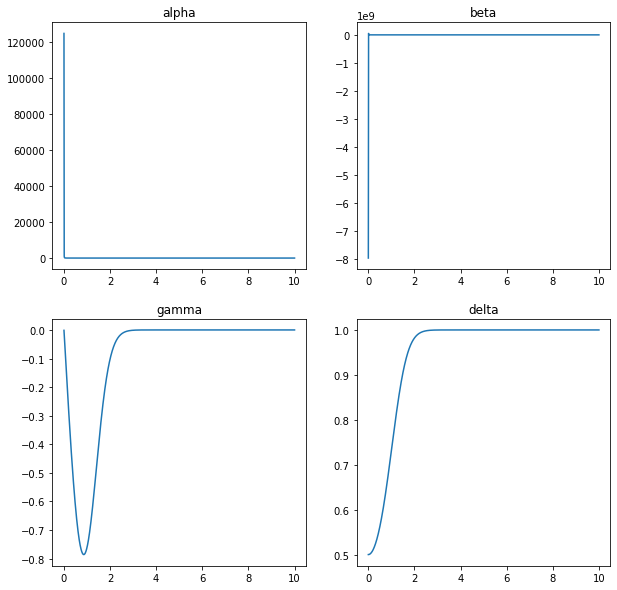

In [5]:
# plot all alpha beta on separate subplots
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax[0, 0].plot(t, alpha)
ax[0, 0].set_title("alpha")
ax[0, 1].plot(t, beta)
ax[0, 1].set_title("beta")
ax[1, 0].plot(t, gamma)
ax[1, 0].set_title("gamma")
ax[1, 1].plot(t, delta)
ax[1, 1].set_title("delta")
plt.show()

In [6]:
alpha.dtype

torch.float64

In [7]:
val = torch.tensor([0.000001])
print(model._alpha(val))
print(model._beta(val))

tensor([1.2500e+11])
tensor([-5650.4303])


Now we test the behavior of the various expressions that appear in the solution.

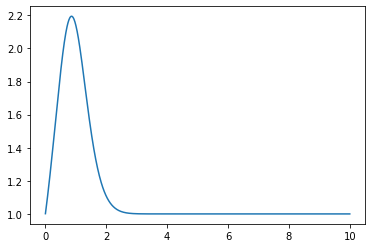

False

In [ ]:
expr = torch.exp(-gamma * u**2)
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

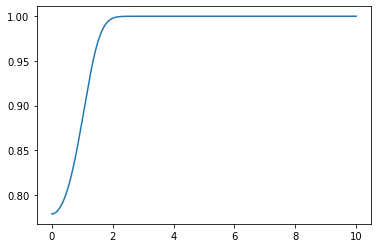

False

In [ ]:
expr = torch.exp(-alpha * gamma**2)
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

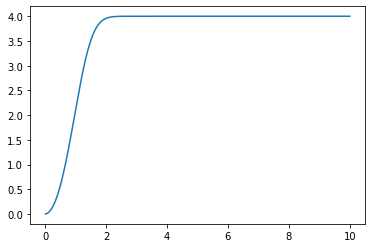

tensor(True)

In [ ]:
expr = 1 / (torch.sqrt((model.r0**2 - model.r(t) ** 2) * (alpha * beta)))
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

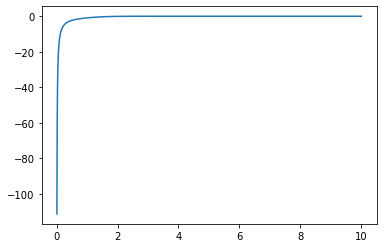

tensor(True)

In [11]:
expr = gamma * torch.sqrt(alpha + beta)
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

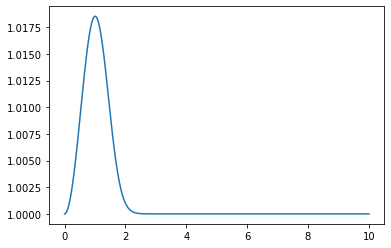

False

In [ ]:
expr = torch.exp(alpha**2 * gamma**2 / (alpha + beta))
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

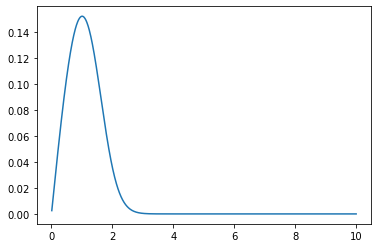

tensor(True)

In [13]:
expr = torch.special.erf(torch.sqrt(alpha**2 * gamma**2 / (alpha + beta)))
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

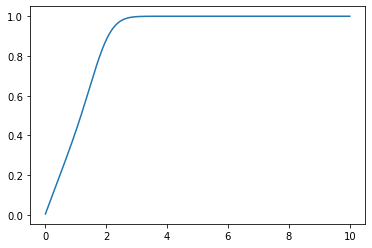

tensor(True)

In [14]:
expr = torch.sqrt(alpha / beta)
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

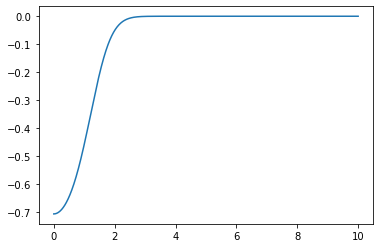

False

In [15]:
expr = gamma * torch.sqrt(2 * alpha * beta / (alpha + beta))
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

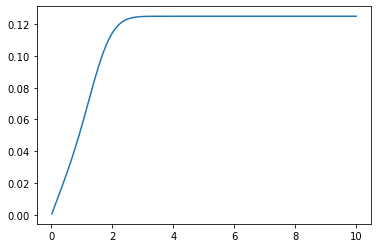

tensor(True)

In [16]:
expr = scipy.special.owens_t(
    gamma * torch.sqrt(2 * alpha * beta / (alpha + beta)), torch.sqrt(alpha / beta)
)
plt.plot(t, expr)
plt.show()
# print true if any value is nan or not finite
torch.isnan(expr).any() or not torch.isfinite(expr).any()

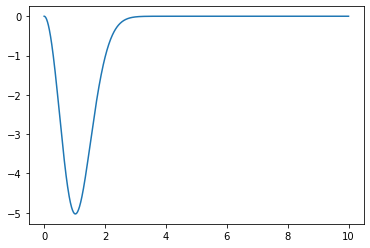

False

In [17]:
expr = (alpha - beta - 2 * alpha * beta * gamma**2) / (alpha * beta)
plt.plot(t, expr)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

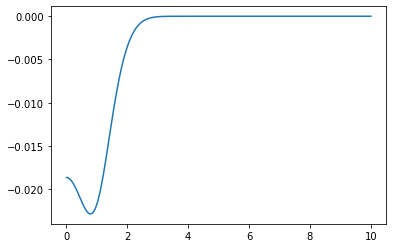

False

In [26]:
expr1 = alpha**2 * gamma**2 / (alpha + beta)

final_integral = (
    torch.exp(-delta * u**2)
    / (4 * torch.pi**2 * torch.sqrt(r0**2 - r**2))
    * (
        (torch.exp(-alpha * gamma**2) / (2 * torch.sqrt(alpha * beta)))
        * (
            1 + np.sqrt(torch.pi) * gamma * torch.sqrt(alpha + beta) * torch.exp(expr1) * torch.special.erf(torch.sqrt(expr1))
        )
        + torch.pi * ((alpha - beta - 2 * alpha * beta * gamma**2) / (alpha * beta))
        * scipy.special.owens_t(gamma * torch.sqrt(2 * alpha * beta / (alpha + beta)), torch.sqrt(alpha / beta))
    )
) - (1 / (4 * torch.pi**2)) * (q0 / r0) * torch.exp(-(u**2) / r0)


plt.plot(t, final_integral)
plt.show()
torch.isnan(expr).any() or not torch.isfinite(expr).any()

In [ ]:
# integrate this function ignoring any nan values
integral = torch.trapz(final_integral[~torch.isnan(final_integral)], t[~torch.isnan(final_integral)])
integral

tensor(-0.0342)